In [12]:
from tensorflow.keras.layers import Conv2D

filters = 32
kernel_size = (3, 3)

layer = Conv2D(filters, kernel_size, strides=(1,1), padding="valid", activation=None, use_bias=True,
kernel_initializer="glorot_uniform")

In [13]:
from tensorflow.keras.layers import MaxPooling2D, AveragePooling2D
max_pool = MaxPooling2D(pool_size=(2,2), strides=None, padding="valid")
avg_pool = AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

In [19]:
import tensorflow as tf

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(32, activation='relu', input_shape=(num_features,)))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
model.compile(optimizer='SGD', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
import tensorflow as tf
import numpy as np

# Create dummy data for demonstration purposes to resolve the NameError.
# In a real scenario, you would load your actual training and validation datasets here.
# For example, using tf.keras.datasets or tf.data.experimental.make_csv_dataset.
num_samples = 100
num_features = 10 # Example number of features for a simple model
num_classes = 2   # Example number of classes for sparse_categorical_crossentropy

# Dummy training data
dummy_x_train = np.random.rand(num_samples, num_features).astype(np.float32)
dummy_y_train = np.random.randint(0, num_classes, num_samples).astype(np.int32)
train_ds = tf.data.Dataset.from_tensor_slices((dummy_x_train, dummy_y_train)).batch(32)

# Dummy validation data
dummy_x_val = np.random.rand(num_samples // 4, num_features).astype(np.float32)
dummy_y_val = np.random.randint(0, num_classes, num_samples // 4).astype(np.int32)
val_ds = tf.data.Dataset.from_tensor_slices((dummy_x_val, dummy_y_val)).batch(32)

model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4800 - loss: 0.7114 - val_accuracy: 0.5600 - val_loss: 0.7091
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4900 - loss: 0.7098 - val_accuracy: 0.5600 - val_loss: 0.7111
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4700 - loss: 0.7085 - val_accuracy: 0.5200 - val_loss: 0.7131
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4300 - loss: 0.7073 - val_accuracy: 0.5200 - val_loss: 0.7150
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4500 - loss: 0.7062 - val_accuracy: 0.4800 - val_loss: 0.7169
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4500 - loss: 0.7052 - val_accuracy: 0.4000 - val_loss: 0.7188
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4300 - loss: 0.7043 - val_accuracy: 0.4000 - val_loss: 0.7206
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4300 - loss: 0.7036 - val_accuracy: 0.4000 - val_loss: 0.7223
Epoch 9

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 33ms/step - accuracy: 0.9588 - loss: 0.1368 - val_accuracy: 0.9868 - val_loss: 0.0425
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9865 - loss: 0.0446 - val_accuracy: 0.9881 - val_loss: 0.0402
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9897 - loss: 0.0313 - val_accuracy: 0.9897 - val_loss: 0.0339
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9930 - loss: 0.0224 - val_accuracy: 0.9910 - val_loss: 0.0265
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9947 - loss: 0.0161 - val_accuracy: 0.9900 - val_loss: 0.0321
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9900 - loss: 0.0321
Test accuracy: 0.9900
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


In [22]:
input_shape=(28, 28, 1)
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits

<Dense name=dense_6, built=False>

#Task1

In [23]:
import zipfile
import os

# Path to your zip file
zip_path = "FruitinAmazon.zip"

# Folder where it will be extracted
extract_path = "dataset"

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [26]:
print(os.listdir("dataset"))

['FruitinAmazon']


In [27]:
train_dir = "dataset/FruitinAmazon/train"

In [28]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

In [29]:
classes = [cls for cls in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, cls))]

print("Classes found:", classes)
print("Total classes:", len(classes))

Classes found: ['guarana', 'pupunha', 'graviola', 'tucuma', 'acai', 'cupuacu']
Total classes: 6


In [30]:
sample_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)

    # Randomly select one image
    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    sample_images.append((cls, img_path))

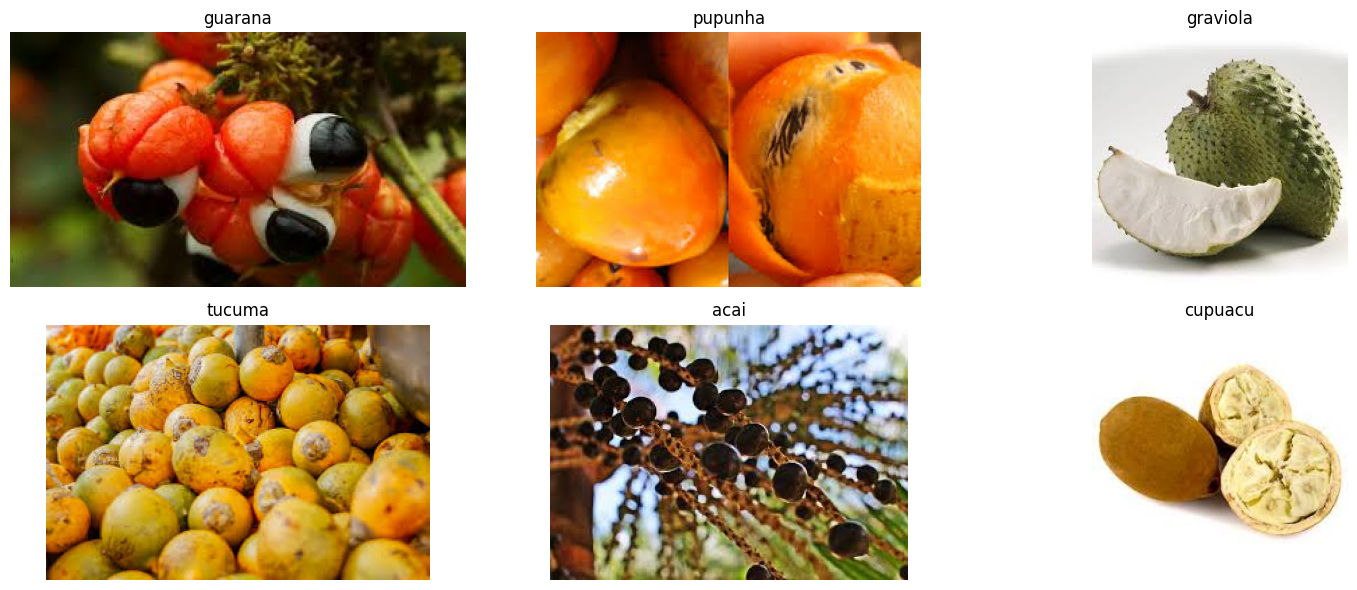

In [31]:
num_images = len(sample_images)
cols = (num_images + 1) // 2  # ensures 2 rows

plt.figure(figsize=(15, 6))

for i, (cls, img_path) in enumerate(sample_images):
    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

I observed that the dataset is divided into different class folders, each containing images of a specific fruit. The images vary in size, color, and background. This variation makes the dataset more realistic but also means preprocessing will be needed before training.

In [32]:
from PIL import Image
import os

corrupted_images = []

# Loop through each class folder
for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    # Skip if not a directory
    if not os.path.isdir(class_path):
        continue

    # Loop through images in each class
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            # Try opening the image
            with Image.open(img_path) as img:
                img.verify()   # verifies if image is valid

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)  # remove corrupted image
            print(f"Removed corrupted image: {img_path}")

# Final result
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


#task2

In [33]:
import tensorflow as tf

In [34]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

In [35]:
rescale = tf.keras.layers.Rescaling(1./255)

In [36]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [37]:
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

In [38]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [39]:
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

In this step, I used Keras’s image_dataset_from_directory function to load images directly from the dataset folder. The function automatically assigns labels based on subfolder names. I resized all images to 128×128 and grouped them into batches of 32. I also split the dataset into training (80%) and validation (20%). Additionally, I applied normalization using a rescaling layer to convert pixel values from [0–255] to [0–1], which helps improve model performance and training stability.

In [40]:
num_classes = len(classes)
print("Number of classes:", num_classes)

Number of classes: 6


In [41]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # 🔸 Convolution Layer 1
    layers.Conv2D(32, (3,3), padding='same', strides=1, input_shape=(128,128,3)),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # 🔸 Convolution Layer 2
    layers.Conv2D(32, (3,3), padding='same', strides=1),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # 🔸 Flatten
    layers.Flatten(),

    # 🔸 Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # 🔸 Output Layer
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 748ms/step - accuracy: 0.2083 - loss: 2.1405 - val_accuracy: 0.0000e+00 - val_loss: 1.9448
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 751ms/step - accuracy: 0.2361 - loss: 1.6952 - val_accuracy: 0.3333 - val_loss: 1.6460
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step - accuracy: 0.3056 - loss: 1.5916 - val_accuracy: 0.6111 - val_loss: 1.6189
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 431ms/step - accuracy: 0.5000 - loss: 1.4092 - val_accuracy: 0.7778 - val_loss: 1.2447
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 410ms/step - accuracy: 0.6806 - loss: 1.2281 - val_accuracy: 0.6667 - val_loss: 1.3357
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6944 - loss: 1.0225 - val_accuracy: 0.7222 - val_loss: 1.1148
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step - accuracy: 0.7778 - loss: 0.7668 - val_accuracy: 0.4444 - val_loss: 1.3982
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 415ms/step - accuracy: 0.8056 - loss: 0.6102 - val_accuracy: 0.8333 - val_loss

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

In this task, I implemented a Convolutional Neural Network (CNN) for image classification. The model consists of two convolutional layers with ReLU activation followed by max pooling layers to extract important features from the images. After feature extraction, a flatten layer is used to convert the data into a 1D vector, which is passed through fully connected dense layers with 64 and 128 neurons. Finally, a softmax output layer is used to classify the images into different fruit categories. The model was compiled using the Adam optimizer and trained using sparse categorical cross-entropy loss.

#Task4

In [45]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [47]:
# Save best model
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Stop early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In this step, I compiled the model using the Adam optimizer, sparse categorical cross-entropy loss, and accuracy as the evaluation metric. The model was trained using the model.fit() function for up to 250 epochs with a batch size of 16. I used the validation dataset to monitor performance during training.

#Task5

In [48]:
test_dir = "dataset/FruitinAmazon/test"   # adjust if needed

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [49]:
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

In [50]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step - accuracy: 0.5000 - loss: 1.3878
Test Loss: 1.3877952098846436
Test Accuracy: 0.5


After training the model, I evaluated its performance on the test dataset using the model.evaluate() function. The test dataset contains unseen data, which helps measure how well the model generalizes. The evaluation provided both test loss and accuracy values. A higher accuracy and lower loss indicate better model performance.

#Task6

In [51]:
model.save("fruit_cnn_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [52]:
from tensorflow.keras.models import load_model

loaded_model = load_model("fruit_cnn_model.h5")

print("Model loaded successfully!")

Model loaded successfully!


In [53]:
test_loss, test_accuracy = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", test_loss)
print("Loaded Model Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step - accuracy: 0.5000 - loss: 1.3878
Loaded Model Test Loss: 1.3877952098846436
Loaded Model Test Accuracy: 0.5


#Task7

In [54]:
import numpy as np
from sklearn.metrics import classification_report

In [55]:
# Predict probabilities
y_pred_probs = model.predict(test_ds)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step


In [56]:
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [58]:
class_names = classes
print("Classes:", class_names)

Classes: ['guarana', 'pupunha', 'graviola', 'tucuma', 'acai', 'cupuacu']


In [59]:
report = classification_report(y_true, y_pred, target_names=class_names)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

     guarana       0.75      0.60      0.67         5
     pupunha       0.42      1.00      0.59         5
    graviola       1.00      0.60      0.75         5
      tucuma       0.44      0.80      0.57         5
        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5

    accuracy                           0.50        30
   macro avg       0.44      0.50      0.43        30
weighted avg       0.44      0.50      0.43        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The classification report shows that the model achieved an overall accuracy of 50%, indicating moderate performance. Some classes such as graviola were predicted well with high precision, while others like acai and cupuacu were not predicted correctly at all. This imbalance in performance suggests that the model struggled to generalize across all classes. One major reason for this could be the small dataset size, as each class contains only a few images. Increasing the dataset size and improving model complexity could help improve performance.